## Breast Cancer Wisconsin dataset

このデータセットは、乳房腫瘤の **FNA（fine needle aspirate, 穿刺吸引細胞診）画像** から抽出した細胞核の特徴量を使って、腫瘍が悪性か良性かを判定するためのもの

- サンプル数: 569
- 説明変数: 30 個
- 目的変数: `target`
- クラス:
  - `0`: malignant（悪性）
  - `1`: benign（良性）

各細胞核について、次の 10 種類の特徴が計算されている

- `radius`: 中心から輪郭上の点までの距離の平均
- `texture`: 画像の濃淡値の標準偏差
- `perimeter`: 周囲長
- `area`: 面積
- `smoothness`: 半径の局所的な変動
- `compactness`: $\frac{\mathrm{perimeter}^2}{\mathrm{area}} - 1$
- `concavity`: 輪郭のへこみの強さ
- `concave points`: 輪郭のへこんだ点の数
- `symmetry`: 対称性
- `fractal dimension`: 輪郭の複雑さを表す指標

上の 10 種類の基本特徴について、それぞれ次の 3 種類が計算されているため、全部で $10 \times 3 = 30$ 変数ある

- `mean`: 平均値
- `error`: 標準誤差 (`se` と表現されることもあります)
- `worst`: 最も大きい側の値の代表

## 使用するライブラリの読み込み

データ処理、可視化、データ分割、評価指標、Random Forest モデルに必要なライブラリを読み込んでいる。

ここで特に重要なのは次の 3 つ

- `load_breast_cancer`: scikit-learn に内蔵されているデータセットを読み込む
- `train_test_split`: 学習用データとテスト用データに分割する
- `RandomForestClassifier`: Random Forest による分類モデルを作る


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.ensemble import RandomForestClassifier

## データセットの読み込みと確認

このセルでは、Breast Cancer Wisconsin dataset を読み込み、説明変数 `X` と目的変数 `y` を作っている

- `X`: 30 個の数値特徴量
- `y`: 良性・悪性を表すクラスラベル

さらに、データの行列サイズとクラス分布を表示して、

- サンプル数がいくつか
- クラスの偏りが大きすぎないか

を確認しています。

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())

display(X.head())
display(y.head())
print(data.DESCR)

X shape: (569, 30)
y distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,target
0,0
1,0
2,0
3,0
4,0


.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## 学習データとテストデータへの分割、および Random Forest の学習

このセルでは、データを訓練用と評価用に分割し、その後 Random Forest を学習している。

処理の流れは

- `train_test_split` でデータを訓練用 80%、テスト用 20% に分割する
- `stratify=y` によって、良性・悪性の比率が train と test で大きく崩れないようにする
- `RandomForestClassifier` を定義する
- `fit` によって訓練データでモデルを学習する

ここでは `oob_score=True` を指定しているため、学習後に OOB score と OOB error を確認できる
OOB error は、学習に使われなかったサンプルを使って内部的に見積もる誤差


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_bc = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_bc.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, oob_score=True,
                       random_state=42)

## テストデータでの予測と性能評価

このセルでは、学習済みモデルを使ってテストデータを予測し、分類性能を数値で評価している

主に見ているのは次の指標

- `Accuracy`: 全体として何割正しく分類できたか
- `ROC-AUC`: 良性と悪性をどれだけうまく分離できるか
- `OOB score`, `OOB error`: Random Forest の内部評価
- `classification_report`: precision, recall, f1-score の一覧
- `confusion_matrix`: 実際のクラスと予測クラスの対応表

このセルによって、モデルがどの程度うまく良性・悪性を判別できているかを確認する


In [4]:
y_pred = rf_bc.predict(X_test)
y_proba = rf_bc.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("OOB score:", rf_bc.oob_score_)
print("OOB error:", 1 - rf_bc.oob_score_)
print()
print(classification_report(y_test, y_pred, target_names=data.target_names))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9473684210526315
ROC-AUC: 0.9937169312169313
OOB score: 0.9560439560439561
OOB error: 0.04395604395604391

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion matrix:
[[39  3]
 [ 3 69]]


## ROC 曲線と Precision-Recall 曲線の可視化

このセルでは、分類性能を曲線として可視化する

- `ROC Curve`: しきい値を動かしたときの偽陽性率と真陽性率の関係を見る
- `Precision-Recall Curve`: precision と recall のトレードオフを見る

モデルの性能を単なる指標だけでなく、より詳細に評価するためのセル

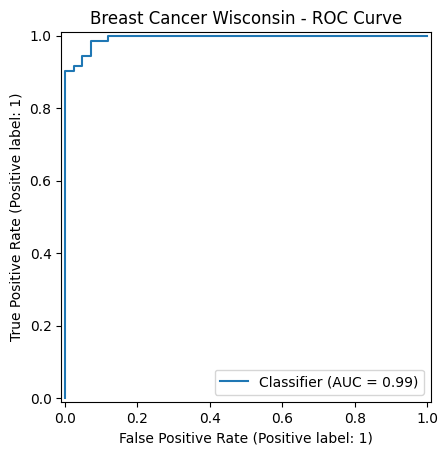

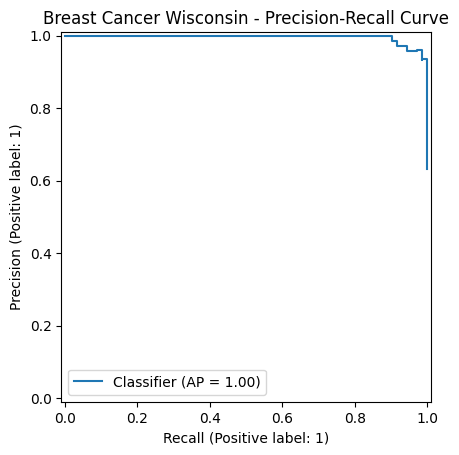

In [5]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Breast Cancer Wisconsin - ROC Curve")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Breast Cancer Wisconsin - Precision-Recall Curve")
plt.show()